In [ ]:
# Step 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
!pip install kaggle --quiet


In [ ]:
#upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kavyasrimarri","key":"5003d9c15cdcca8127280472bf95a68e"}'}

In [ ]:
#create kaggle directory
!mkdir ~/.kaggle
#copy Kaggle.json file
!cp kaggle.json ~/.kaggle/

In [ ]:
ls -ltr ~/.kaggle

total 4
-rw-r--r-- 1 root root 69 Mar 11 09:59 kaggle.json


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#dowload the kaggle dataset
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 378MB/s]


In [ ]:
import os
os.listdir('/content')

['.config', 'kaggle.json', 'telco-customer-churn.zip', 'sample_data']

In [ ]:
!unzip telco-customer-churn.zip

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [ ]:
#Read csv
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
#EDA
df.shape



(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Make a copy of the dataframe
df_clean = df.copy()

# 1. Handle TotalCharges - convert to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Check missing values in TotalCharges
print(f"Missing TotalCharges: {df_clean['TotalCharges'].isnull().sum()}")

# Fill missing TotalCharges with median (or drop if very few)
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# 2. Drop customerID (not useful for modeling)
df_clean.drop('customerID', axis=1, inplace=True)

# 3. Convert target variable to binary
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 4. Check for any other missing values
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Missing TotalCharges: 11

Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


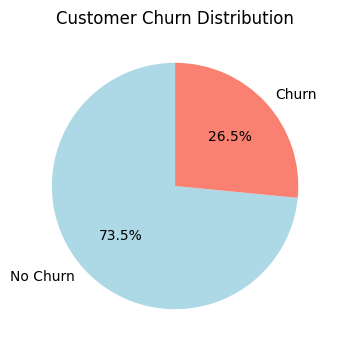

Churn Rate: 26.54%


In [ ]:
# 1. Churn Distribution
plt.figure(figsize=(6, 4))
churn_counts = df_clean['Churn'].value_counts()
plt.pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
        colors=['lightblue', 'salmon'], startangle=90)
plt.title('Customer Churn Distribution')
plt.show()

print(f"Churn Rate: {churn_counts[1]/len(df_clean)*100:.2f}%")



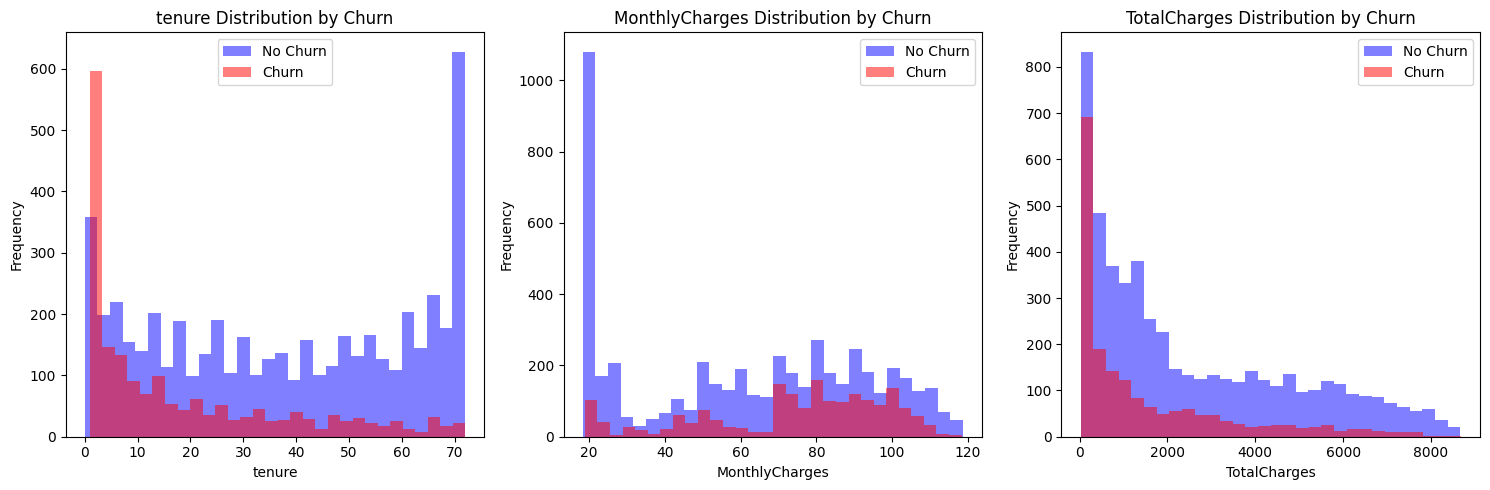

In [ ]:
# 2. Numeric features distribution by churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    for churn_val, color, label in [(0, 'blue', 'No Churn'), (1, 'red', 'Churn')]:
        subset = df_clean[df_clean['Churn'] == churn_val]
        axes[i].hist(subset[col], alpha=0.5, color=color, label=label, bins=30)
    axes[i].set_title(f'{col} Distribution by Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()



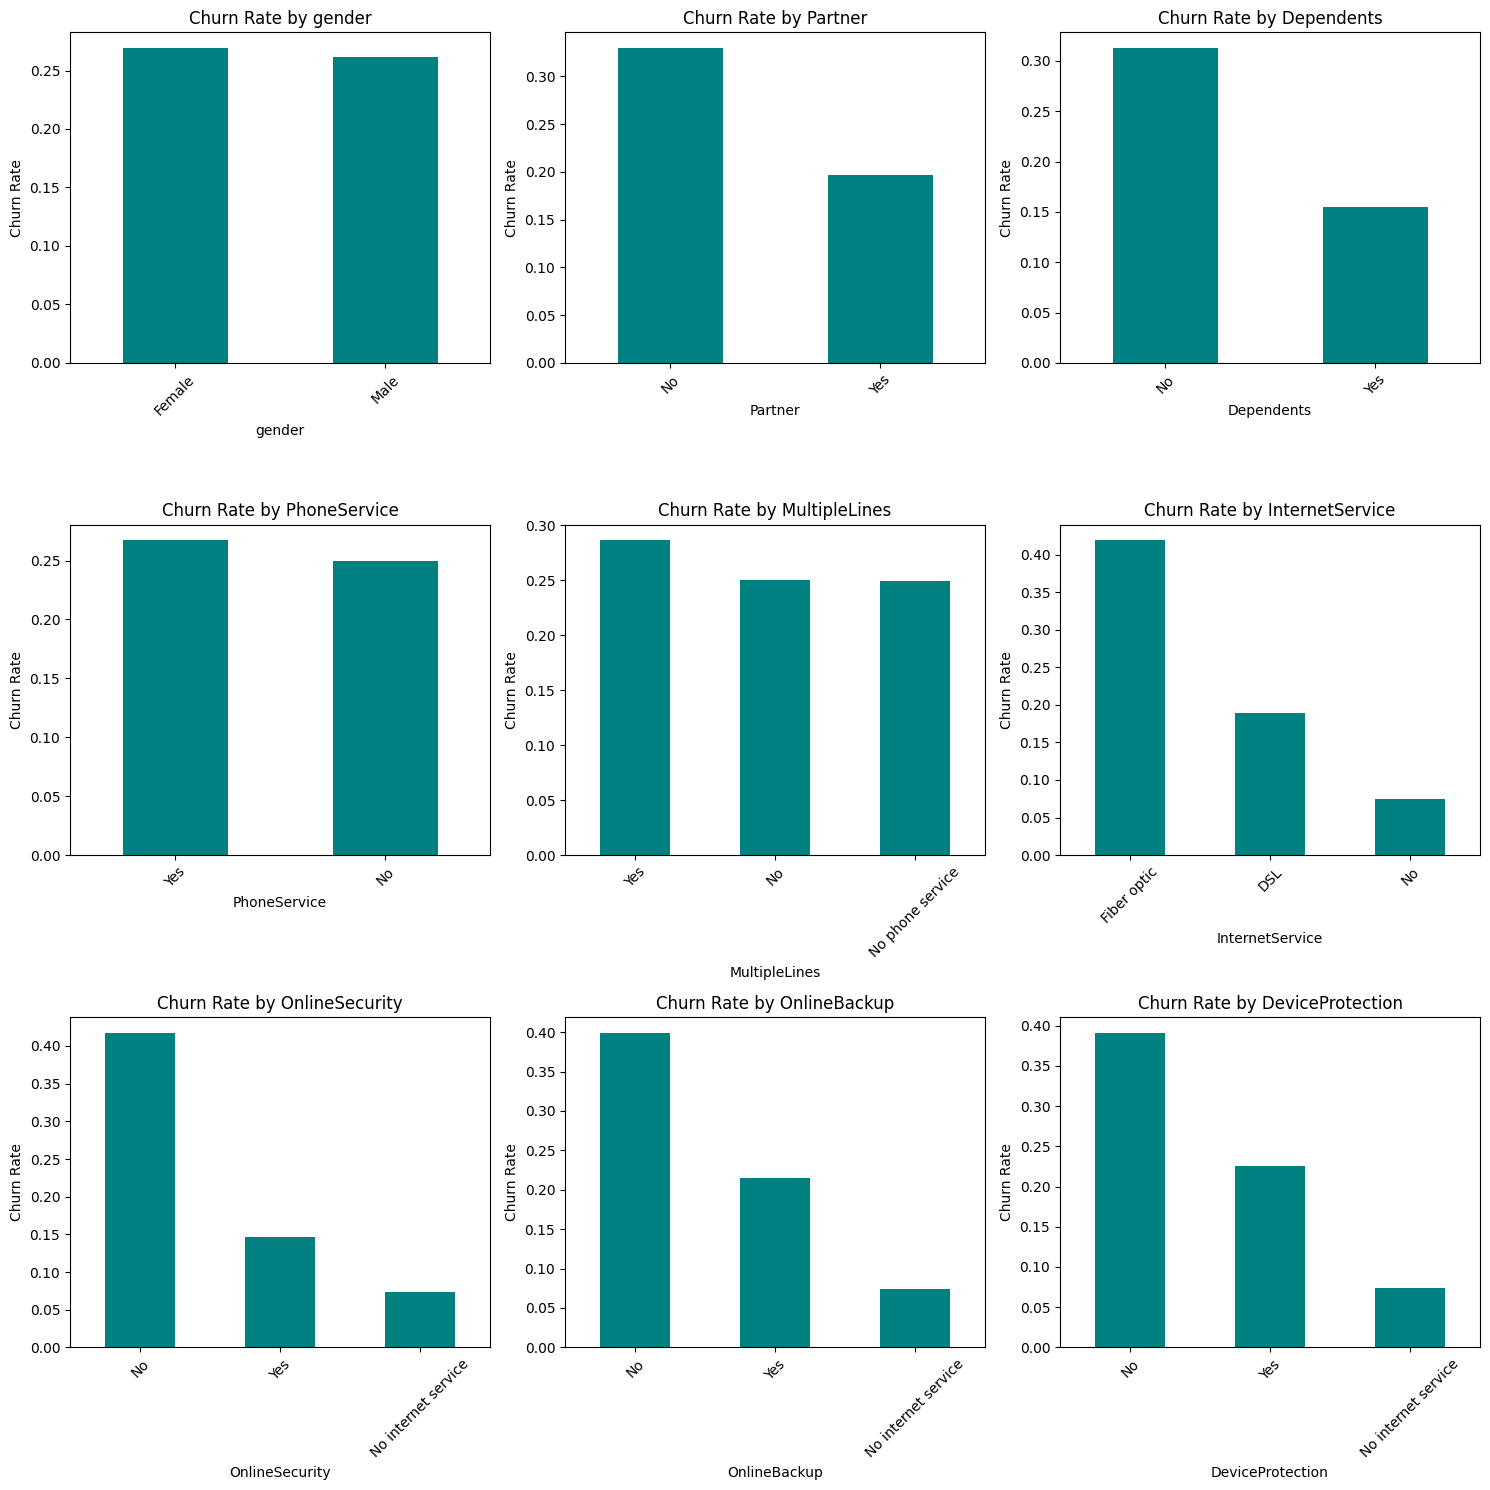

In [ ]:
# 3. Categorical features analysis
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:9]):  # Plot first 9 categorical features
    churn_rate = df_clean.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='teal')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

📊 CUSTOMER CHURN ANALYSIS - TELCO DATASET

📋 DATASET OVERVIEW:
Total Customers: 7,043
Total Features: 21
Memory Usage: 6.82 MB

📊 DATA TYPES:
object     18
int64       2
float64     1
Name: count, dtype: int64

🔍 MISSING VALUES:
No missing values found!

🎯 TARGET VARIABLE (Churn) DISTRIBUTION:


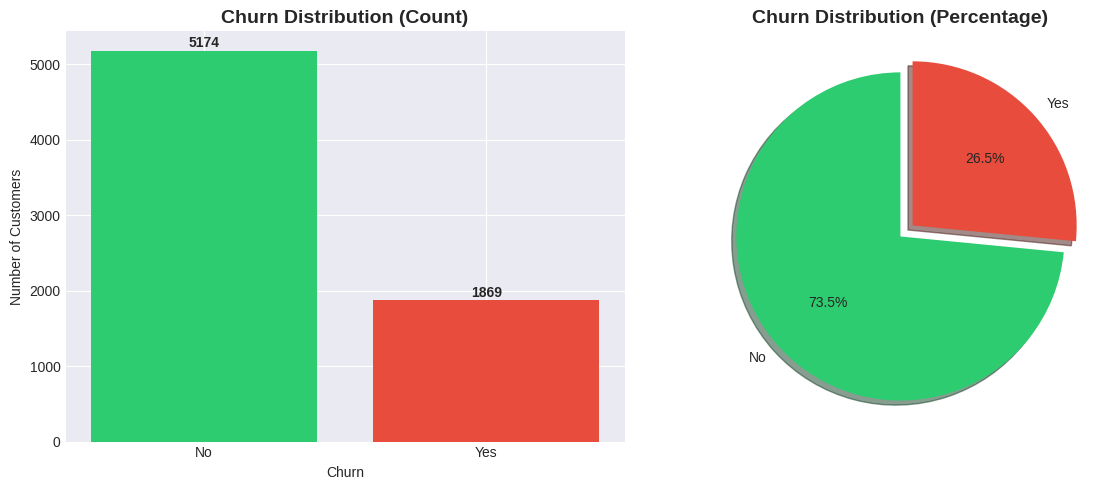


Churn Rate: 26.54%
Retention Rate: 73.46%

📈 NUMERICAL FEATURES SUMMARY:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


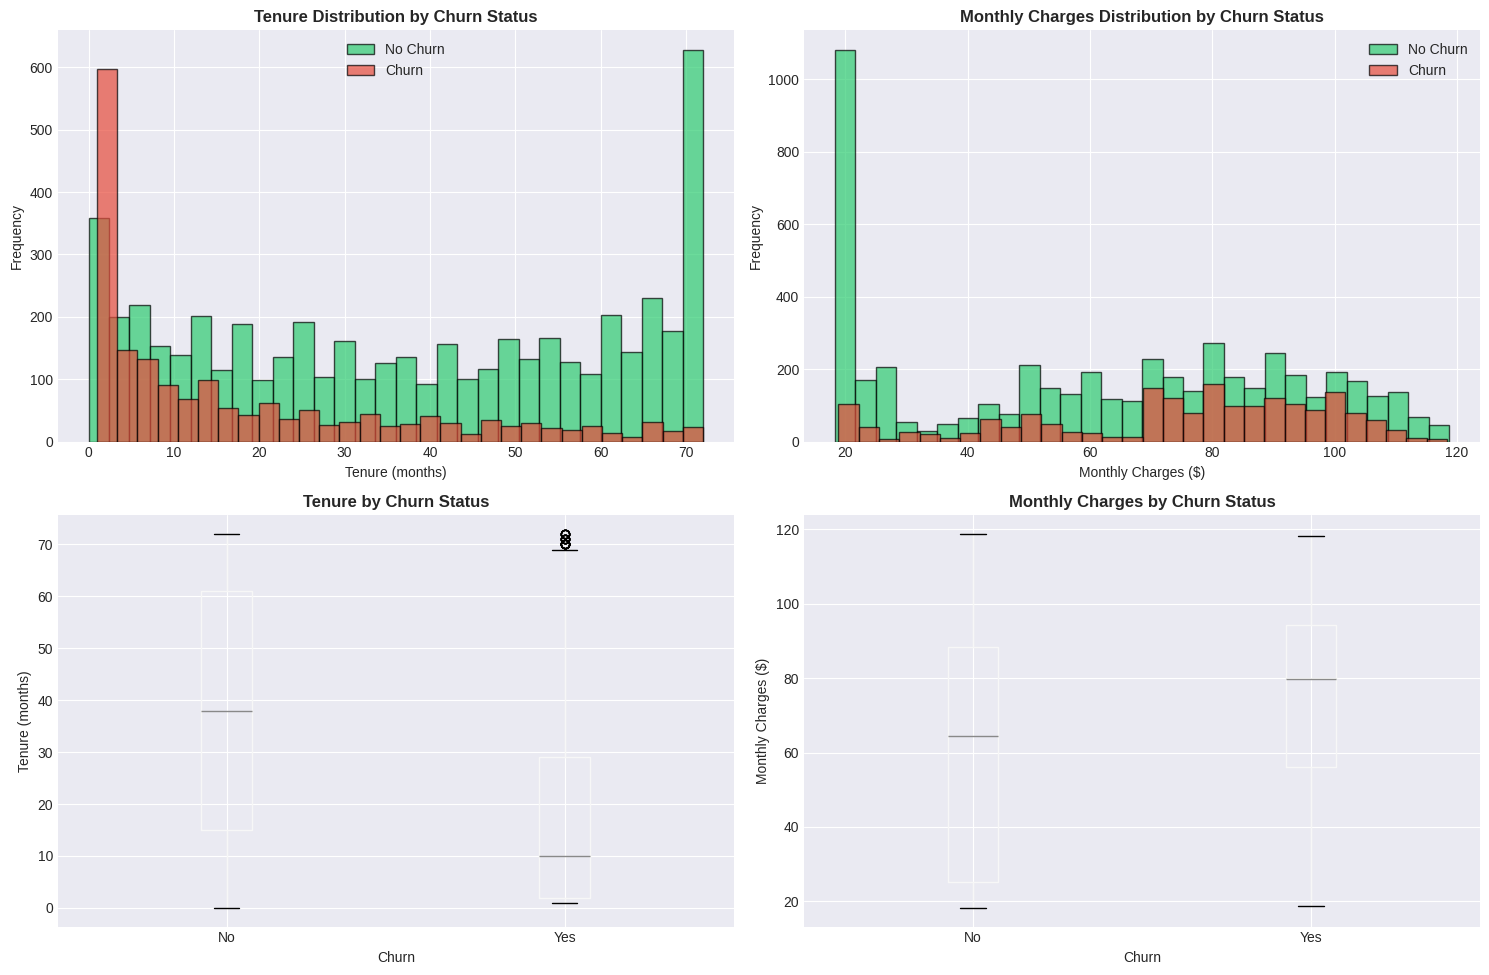


📊 CATEGORICAL FEATURES CHURN RATE ANALYSIS:


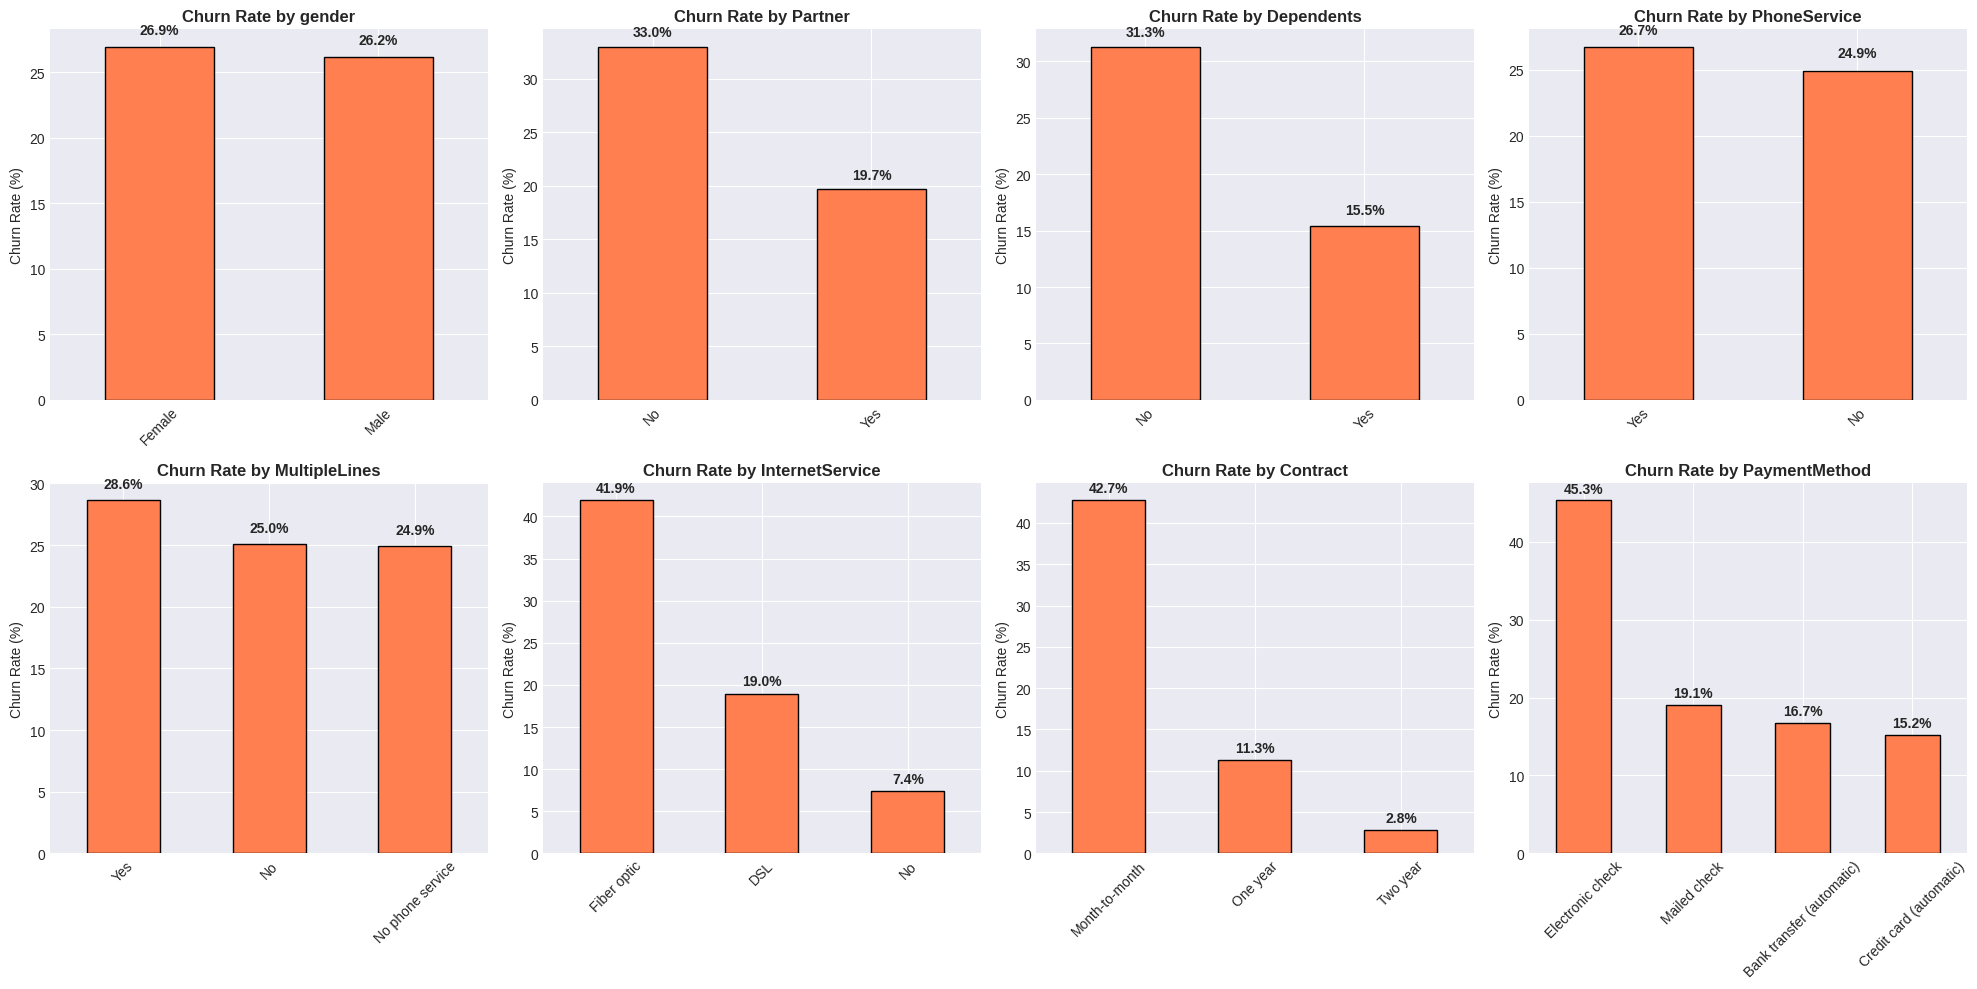


📋 CONTRACT TYPE IMPACT:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

🌐 INTERNET SERVICE IMPACT:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

🔗 CORRELATION MATRIX (Numerical Features):


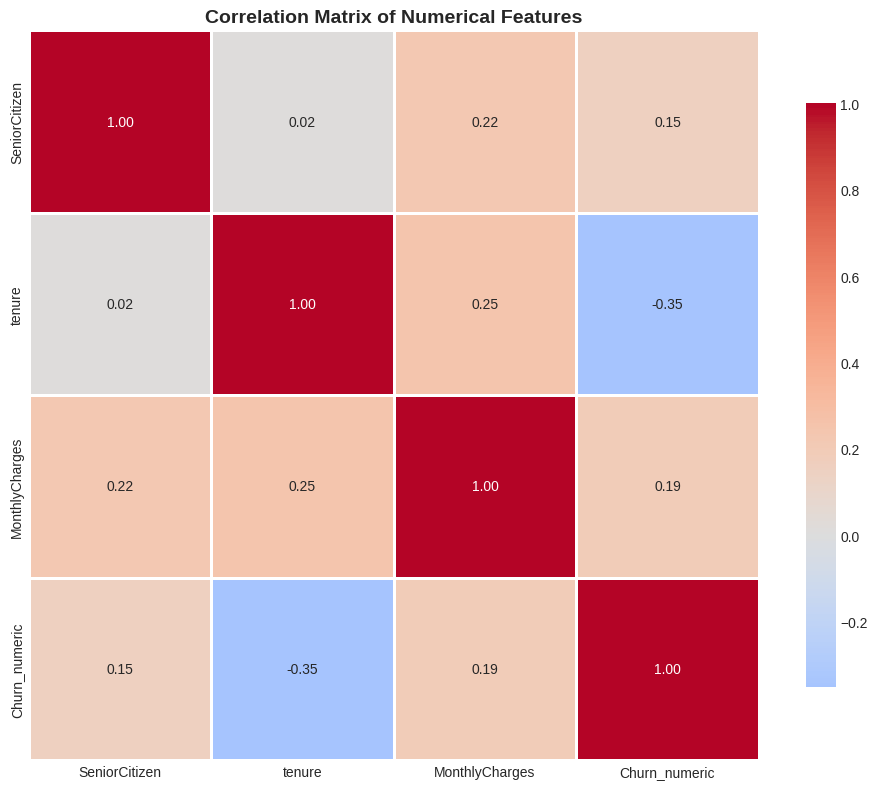


✅ Initial Analysis Complete! Ready for Feature Engineering & Modeling


In [ ]:
# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("📊 CUSTOMER CHURN ANALYSIS - TELCO DATASET")
print("="*70)

# 1. Basic Information
print("\n📋 DATASET OVERVIEW:")
print(f"Total Customers: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. Data Types Summary
print("\n📊 DATA TYPES:")
print(df.dtypes.value_counts())

# 3. Check for Missing Values
print("\n🔍 MISSING VALUES:")
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("No missing values found!")

# 4. Target Variable Distribution
print("\n🎯 TARGET VARIABLE (Churn) DISTRIBUTION:")
churn_counts = df['Churn'].value_counts()
churn_pcts = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
axes[1].pie(churn_counts.values, explode=explode, labels=churn_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90, shadow=True)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nChurn Rate: {churn_pcts['Yes']:.2f}%")
print(f"Retention Rate: {churn_pcts['No']:.2f}%")

# 5. Numerical Features Analysis
print("\n📈 NUMERICAL FEATURES SUMMARY:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df[numerical_cols].describe())

# Visualize numerical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Tenure distribution by churn
for churn_val, color, label in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c'], ['No Churn', 'Churn']):
    subset = df[df['Churn'] == churn_val]
    axes[0, 0].hist(subset['tenure'], alpha=0.7, color=color, label=label, bins=30, edgecolor='black')
axes[0, 0].set_title('Tenure Distribution by Churn Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tenure (months)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# MonthlyCharges distribution by churn
for churn_val, color, label in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c'], ['No Churn', 'Churn']):
    subset = df[df['Churn'] == churn_val]
    axes[0, 1].hist(subset['MonthlyCharges'], alpha=0.7, color=color, label=label, bins=30, edgecolor='black')
axes[0, 1].set_title('Monthly Charges Distribution by Churn Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Monthly Charges ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Box plot: Tenure vs Churn
df.boxplot(column='tenure', by='Churn', ax=axes[1, 0])
axes[1, 0].set_title('Tenure by Churn Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Tenure (months)')

# Box plot: MonthlyCharges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Churn')
axes[1, 1].set_ylabel('Monthly Charges ($)')

plt.suptitle('')  # Remove automatic suptitle
plt.tight_layout()
plt.show()

# 6. Categorical Features Analysis
print("\n📊 CATEGORICAL FEATURES CHURN RATE ANALYSIS:")
categorical_cols = df.select_dtypes(include=['object']).columns.drop(['customerID', 'Churn'])

# Select key categorical features for visualization
key_categorical = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                   'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_categorical):
    if col in df.columns:
        churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
        churn_rate.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Churn Rate (%)')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for j, v in enumerate(churn_rate.values):
            axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 7. Contract Type Analysis
print("\n📋 CONTRACT TYPE IMPACT:")
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn)

# 8. Internet Service Analysis
print("\n🌐 INTERNET SERVICE IMPACT:")
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
print(internet_churn)

# 9. Correlation Analysis for Numerical Features
print("\n🔗 CORRELATION MATRIX (Numerical Features):")
# Convert Churn to numeric for correlation
df_numeric = df.copy()
df_numeric['Churn_numeric'] = (df_numeric['Churn'] == 'Yes').astype(int)

# Select numerical columns including the new Churn_numeric
numeric_for_corr = numerical_cols.tolist() + ['Churn_numeric']
corr_matrix = df_numeric[numeric_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Initial Analysis Complete! Ready for Feature Engineering & Modeling")

📊 CUSTOMER CHURN ANALYSIS

📋 Dataset: 7,043 customers, 21 features
📊 Memory: 6.82 MB

🔍 Missing Values:
No missing values found!

🎯 Churn Distribution:


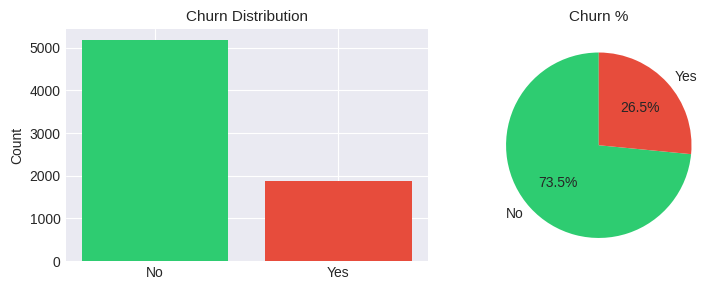

Churn Rate: 26.5% | Retention: 73.5%

📈 Numerical Features by Churn:


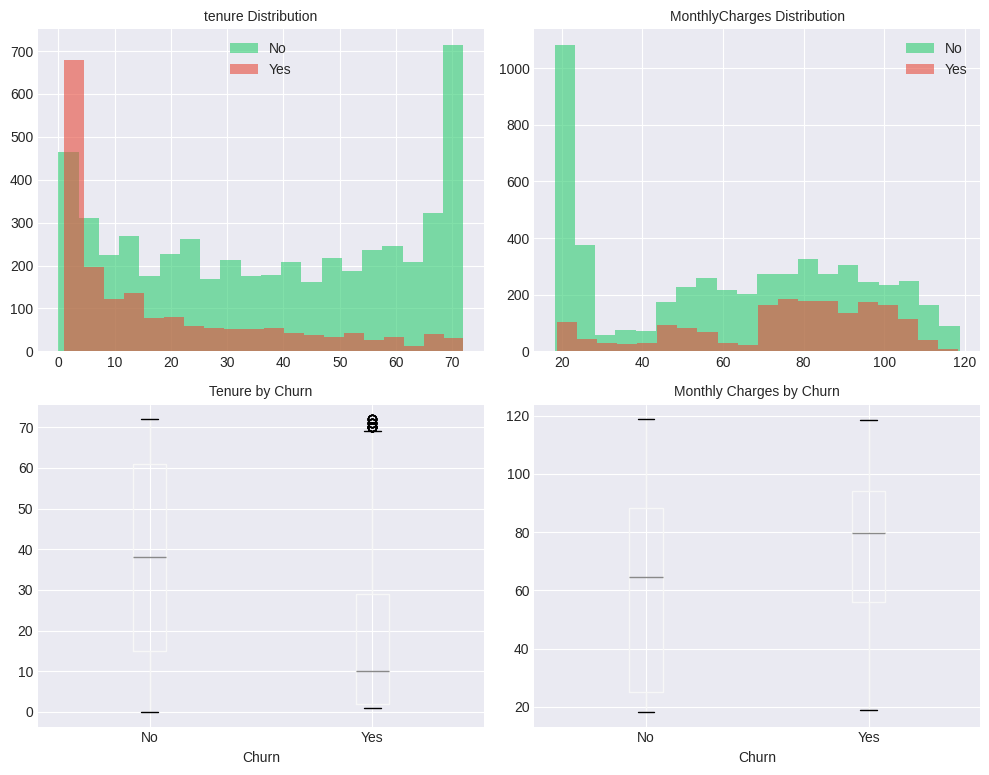


📊 Key Factors Affecting Churn:


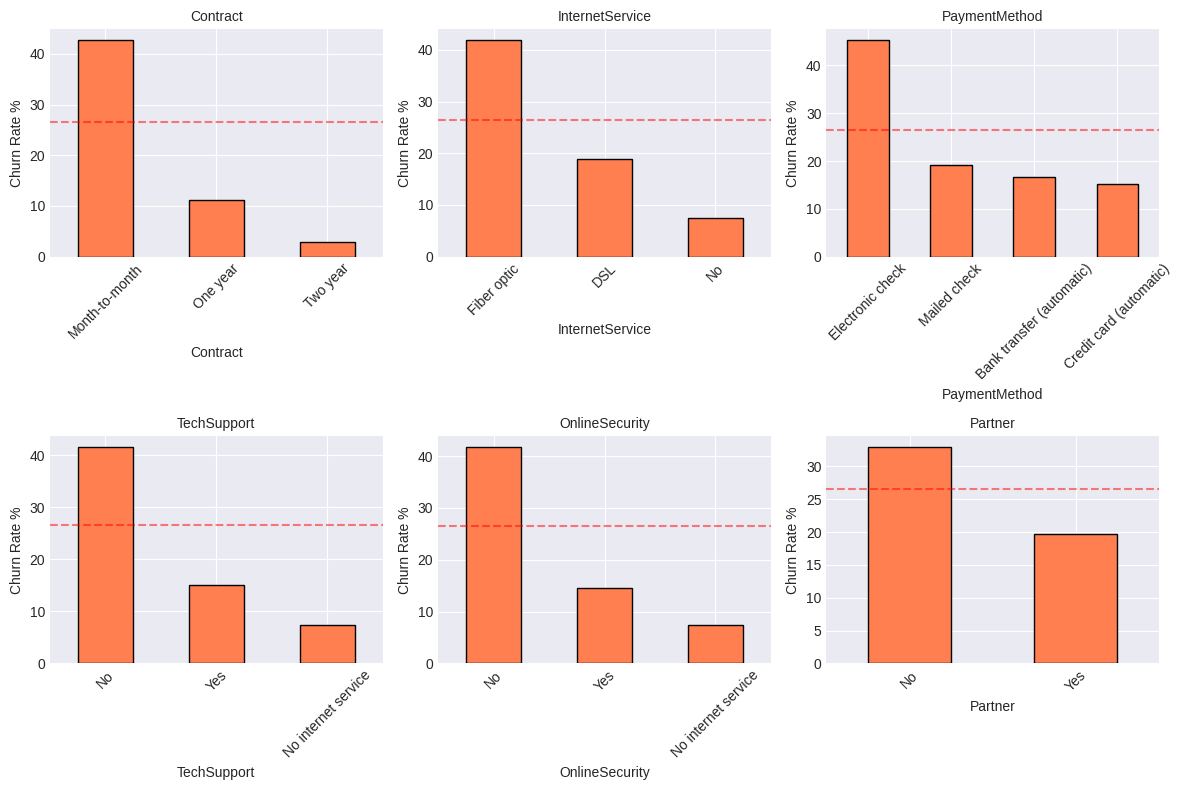


🔑 KEY INSIGHTS:

📋 Contract Type Impact:
   Month-to-month: 42.7% churn
   One year: 11.3% churn
   Two year: 2.8% churn

🌐 Internet Service Impact:
   DSL: 19.0% churn
   Fiber optic: 41.9% churn
   No: 7.4% churn

⚠️ Highest Risk Factors:
   Contract: 42.7% | InternetService: 41.9% | PaymentMethod: 45.3% | TechSupport: 41.6%

🔗 Feature Correlation with Churn:
Churn_binary      1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn_binary, dtype: float64

✅ Analysis Complete! Ready for Modeling


In [ ]:


# Set smaller figure sizes
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

print("="*50)
print("📊 CUSTOMER CHURN ANALYSIS")
print("="*50)

# 1. Basic Information
print(f"\n📋 Dataset: {df.shape[0]:,} customers, {df.shape[1]} features")
print(f"📊 Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. Check Missing Values
print("\n🔍 Missing Values:")
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("No missing values found!")

# 3. Target Distribution (Compact)
print("\n🎯 Churn Distribution:")
churn_counts = df['Churn'].value_counts()
churn_pcts = df['Churn'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
# Bar plot
ax1.bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Churn Distribution', fontsize=11)
ax1.set_ylabel('Count')
# Pie chart
ax2.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Churn %', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Churn Rate: {churn_pcts['Yes']:.1f}% | Retention: {churn_pcts['No']:.1f}%")

# 4. Numerical Features (Compact 2x2)
print("\n📈 Numerical Features by Churn:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
features = ['tenure', 'MonthlyCharges']
for i, feature in enumerate(features):
    for churn_val, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        subset = df[df['Churn'] == churn_val]
        axes[0, i].hist(subset[feature], alpha=0.6, color=color, label=churn_val, bins=20)
    axes[0, i].set_title(f'{feature} Distribution', fontsize=10)
    axes[0, i].legend()

# Box plots
df.boxplot(column='tenure', by='Churn', ax=axes[1, 0])
axes[1, 0].set_title('Tenure by Churn', fontsize=10)
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges by Churn', fontsize=10)
plt.suptitle('')
plt.tight_layout()
plt.show()

# 5. Key Categorical Features (Compact 2x3)
print("\n📊 Key Factors Affecting Churn:")
key_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'Partner']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[i],
                                                  color='coral', edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_ylabel('Churn Rate %')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=churn_pcts['Yes'], color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Key Insights Summary
print("\n" + "="*50)
print("🔑 KEY INSIGHTS:")
print("="*50)

# Contract impact
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(f"\n📋 Contract Type Impact:")
for contract, rate in contract_churn.items():
    print(f"   {contract}: {rate:.1f}% churn")

# Internet service impact
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(f"\n🌐 Internet Service Impact:")
for service, rate in internet_churn.items():
    print(f"   {service}: {rate:.1f}% churn")

# Top risk factors
print(f"\n⚠️ Highest Risk Factors:")
high_risk = []
for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']:
    max_churn = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).max()
    high_risk.append(f"{col}: {max_churn:.1f}%")

print("   " + " | ".join(high_risk))

# 7. Simple Correlation
print("\n🔗 Feature Correlation with Churn:")
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)
numerical_corr = df_corr[numerical_cols.tolist() + ['Churn_binary']].corr()['Churn_binary'].sort_values(ascending=False)
print(numerical_corr)

print("\n" + "="*50)
print("✅ Analysis Complete! Ready for Modeling")
print("="*50)

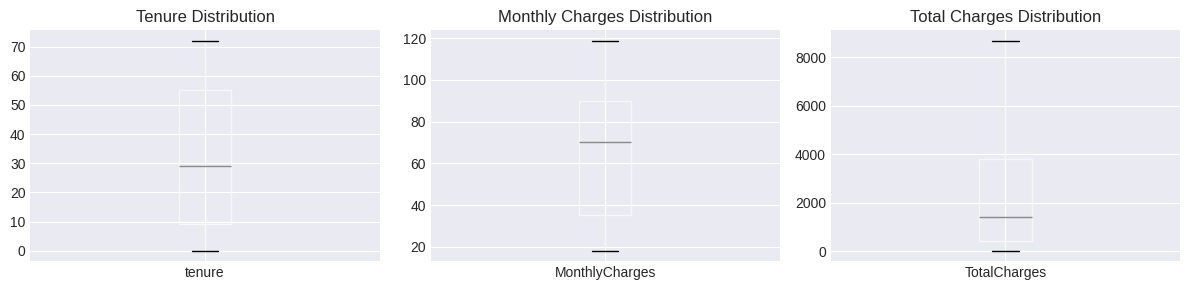

In [ ]:
# Quick visualization to check distributions after cleaning
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Box plots
df_clean.boxplot(column='tenure', ax=axes[0])
axes[0].set_title('Tenure Distribution')

df_clean.boxplot(column='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution')

df_clean.boxplot(column='TotalCharges', ax=axes[2])
axes[2].set_title('Total Charges Distribution')

plt.tight_layout()
plt.show()

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
import pandas as pd
import numpy as np

print("="*60)
print("🧹 STEP 3: DATA CLEANING & PREPROCESSING")
print("="*60)

# a) Create a copy
df_clean = df.copy()
print("a) df_clean = df.copy()")
print(f"   ✅ Copy created")

# b) Check first few rows
print("\nb) df_clean.head():")
print("-" * 40)
print(df_clean.head())
print("-" * 40)

# c) Check shape
print("\nc) df_clean.shape:")
print(f"   {df_clean.shape}")

# d) Remove duplicates
print("\nd) df_clean.drop_duplicates(inplace=True)")
df_clean.drop_duplicates(inplace=True)
print(f"   df_clean.shape after removing duplicates: {df_clean.shape}")

# e) Check missing values
print("\ne) df_clean.isnull().sum():")
missing = df_clean.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "   No missing values found!")

# f) Check data types and value counts
print("\nf) Data types and value counts:")
print("   Data types:")
print(f"   {df_clean.dtypes.value_counts()}")

# Check value counts for key categorical columns
print("\n   Value counts for key columns:")
print("   gender (sex):")
print(df_clean['gender'].value_counts())

print("\n   Partner:")
print(df_clean['Partner'].value_counts())

print("\n   Dependents:")
print(df_clean['Dependents'].value_counts())

print("\n   PhoneService:")
print(df_clean['PhoneService'].value_counts())

# g) Map categorical variables to numeric (like in your image)
print("\ng) Mapping categorical variables to numeric:")

# Map gender
df_clean['gender'] = df_clean['gender'].map({'Male': 0, 'Female': 1})
print("   df_clean['gender'] = df_clean['gender'].map({'Male': 0, 'Female': 1})")
print(f"   gender mapping complete. Values: {df_clean['gender'].unique()}")

# Map Partner
df_clean['Partner'] = df_clean['Partner'].map({'No': 0, 'Yes': 1})
print("   df_clean['Partner'] = df_clean['Partner'].map({'No': 0, 'Yes': 1})")

# Map Dependents
df_clean['Dependents'] = df_clean['Dependents'].map({'No': 0, 'Yes': 1})
print("   df_clean['Dependents'] = df_clean['Dependents'].map({'No': 0, 'Yes': 1})")

# Map PhoneService
df_clean['PhoneService'] = df_clean['PhoneService'].map({'No': 0, 'Yes': 1})
print("   df_clean['PhoneService'] = df_clean['PhoneService'].map({'No': 0, 'Yes': 1})")

# Map PaperlessBilling
df_clean['PaperlessBilling'] = df_clean['PaperlessBilling'].map({'No': 0, 'Yes': 1})
print("   df_clean['PaperlessBilling'] = df_clean['PaperlessBilling'].map({'No': 0, 'Yes': 1})")

# Map Churn (target variable)
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})
print("   df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})")

# h) Rename columns (similar to your example)
print("\nh) Renaming columns:")

# Rename gender to is_female
df_clean.rename(columns={'gender': 'is_female'}, inplace=True)
print("   df_clean.rename(columns={'gender': 'is_female'}, inplace=True)")

# Rename Partner to has_partner
df_clean.rename(columns={'Partner': 'has_partner'}, inplace=True)
print("   df_clean.rename(columns={'Partner': 'has_partner'}, inplace=True)")

# Rename Dependents to has_dependents
df_clean.rename(columns={'Dependents': 'has_dependents'}, inplace=True)
print("   df_clean.rename(columns={'Dependents': 'has_dependents'}, inplace=True)")

# Rename PhoneService to has_phone
df_clean.rename(columns={'PhoneService': 'has_phone'}, inplace=True)
print("   df_clean.rename(columns={'PhoneService': 'has_phone'}, inplace=True)")

# Rename PaperlessBilling to paperless_billing
df_clean.rename(columns={'PaperlessBilling': 'paperless_billing'}, inplace=True)
print("   df_clean.rename(columns={'PaperlessBilling': 'paperless_billing'}, inplace=True)")

# Check the cleaned data
print("\n📊 Final cleaned data:")
print("-" * 40)
print(df_clean.head())
print("-" * 40)
print(f"Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")
print(f"Data types:\n{df_clean.dtypes.value_counts()}")

print("\n" + "="*60)
print("✅ DATA CLEANING COMPLETE!")
print("="*60)

🧹 STEP 3: DATA CLEANING & PREPROCESSING
a) df_clean = df.copy()
   ✅ Copy created

b) df_clean.head():
----------------------------------------
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Ye

In [ ]:
df_clean.head()

,customerID,is_female,SeniorCitizen,has_partner,has_dependents,tenure,has_phone,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,paperless_billing,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   is_female          7043 non-null   int64  
 2   SeniorCitizen      7043 non-null   int64  
 3   has_partner        7043 non-null   int64  
 4   has_dependents     7043 non-null   int64  
 5   tenure             7043 non-null   int64  
 6   has_phone          7043 non-null   int64  
 7   MultipleLines      7043 non-null   object 
 8   InternetService    7043 non-null   object 
 9   OnlineSecurity     7043 non-null   object 
 10  OnlineBackup       7043 non-null   object 
 11  DeviceProtection   7043 non-null   object 
 12  TechSupport        7043 non-null   object 
 13  StreamingTV        7043 non-null   object 
 14  StreamingMovies    7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  paperless_billing  7043 

In [ ]:
print("\n" + "="*60)
print("🔍 VERIFICATION OF CLEANING")
print("="*60)

# 1. Check data types are all numeric
print("\n1. DATA TYPES CHECK:")
dtype_check = df_clean.dtypes.value_counts()
print(dtype_check)
print(f"All numeric: {all(dtype in ['int64', 'float64'] for dtype in df_clean.dtypes)}")

# 2. Check for missing values
print("\n2. MISSING VALUES CHECK:")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")

# 3. Check value ranges for binary columns
print("\n3. BINARY COLUMNS CHECK:")
binary_cols = ['is_female', 'SeniorCitizen', 'has_partner', 'has_dependents',
               'has_phone', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'paperless_billing', 'Churn']

for col in binary_cols:
    if col in df_clean.columns:
        unique_vals = df_clean[col].unique()
        print(f"   {col:20} : {sorted(unique_vals)}")

# 4. Check target distribution
print("\n4. TARGET VARIABLE DISTRIBUTION:")
churn_counts = df_clean['Churn'].value_counts()
churn_pcts = df_clean['Churn'].value_counts(normalize=True) * 100
print(f"   Class 0 (No Churn): {churn_counts[0]:,} ({churn_pcts[0]:.1f}%)")
print(f"   Class 1 (Churn): {churn_counts[1]:,} ({churn_pcts[1]:.1f}%)")

print("\n" + "="*60)
print("✅ DATA CLEANING COMPLETED SUCCESSFULLY!")
print("="*60)
print("\nNow ready for Train-Test Split and Modeling!")


🔍 VERIFICATION OF CLEANING

1. DATA TYPES CHECK:
object     12
int64       8
float64     1
Name: count, dtype: int64
All numeric: False

2. MISSING VALUES CHECK:
Total missing values: 0

3. BINARY COLUMNS CHECK:
   is_female            : [np.int64(0), np.int64(1)]
   SeniorCitizen        : [np.int64(0), np.int64(1)]
   has_partner          : [np.int64(0), np.int64(1)]
   has_dependents       : [np.int64(0), np.int64(1)]
   has_phone            : [np.int64(0), np.int64(1)]
   MultipleLines        : ['No', 'No phone service', 'Yes']
   OnlineSecurity       : ['No', 'No internet service', 'Yes']
   OnlineBackup         : ['No', 'No internet service', 'Yes']
   DeviceProtection     : ['No', 'No internet service', 'Yes']
   TechSupport          : ['No', 'No internet service', 'Yes']
   StreamingTV          : ['No', 'No internet service', 'Yes']
   StreamingMovies      : ['No', 'No internet service', 'Yes']
   paperless_billing    : [np.int64(0), np.int64(1)]
   Churn                : [np.i

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   is_female          7043 non-null   int64  
 2   SeniorCitizen      7043 non-null   int64  
 3   has_partner        7043 non-null   int64  
 4   has_dependents     7043 non-null   int64  
 5   tenure             7043 non-null   int64  
 6   has_phone          7043 non-null   int64  
 7   MultipleLines      7043 non-null   object 
 8   InternetService    7043 non-null   object 
 9   OnlineSecurity     7043 non-null   object 
 10  OnlineBackup       7043 non-null   object 
 11  DeviceProtection   7043 non-null   object 
 12  TechSupport        7043 non-null   object 
 13  StreamingTV        7043 non-null   object 
 14  StreamingMovies    7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  paperless_billing  7043 

In [ ]:
import pandas as pd
import numpy as np

print("="*60)
print("🧹 STEP 3: DATA CLEANING & PREPROCESSING")
print("="*60)

# a) Create a copy
df_clean = df.copy()
print("a) df_clean = df.copy()")
print(f"   ✅ Copy created")

# b) Check first few rows
print("\nb) df_clean.head():")
print("-" * 40)
print(df_clean.head())
print("-" * 40)

# c) Check shape
print("\nc) df_clean.shape:")
print(f"   {df_clean.shape}")

# d) Remove duplicates
print("\nd) df_clean.drop_duplicates(inplace=True)")
df_clean.drop_duplicates(inplace=True)
print(f"   df_clean.shape after removing duplicates: {df_clean.shape}")

# e) Check missing values
print("\ne) df_clean.isnull().sum():")
missing = df_clean.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "   No missing values found!")

# f) Check data types and value counts
print("\nf) Data types and value counts:")
print("   Data types:")
print(f"   {df_clean.dtypes.value_counts()}")

# Check value counts for key categorical columns
print("\n   Value counts for key columns:")
print("   gender (sex):")
print(df_clean['gender'].value_counts())

print("\n   Partner:")
print(df_clean['Partner'].value_counts())

print("\n   Dependents:")
print(df_clean['Dependents'].value_counts())

print("\n   PhoneService:")
print(df_clean['PhoneService'].value_counts())

# g) Map binary categorical variables to numeric
print("\ng) Mapping binary categorical variables to numeric:")

# Map gender
df_clean['gender'] = df_clean['gender'].map({'Male': 0, 'Female': 1})
print("   df_clean['gender'] = df_clean['gender'].map({'Male': 0, 'Female': 1})")
print(f"   gender mapping complete. Values: {df_clean['gender'].unique()}")

# Map Partner
df_clean['Partner'] = df_clean['Partner'].map({'No': 0, 'Yes': 1})
print("   df_clean['Partner'] = df_clean['Partner'].map({'No': 0, 'Yes': 1})")

# Map Dependents
df_clean['Dependents'] = df_clean['Dependents'].map({'No': 0, 'Yes': 1})
print("   df_clean['Dependents'] = df_clean['Dependents'].map({'No': 0, 'Yes': 1})")

# Map PhoneService
df_clean['PhoneService'] = df_clean['PhoneService'].map({'No': 0, 'Yes': 1})
print("   df_clean['PhoneService'] = df_clean['PhoneService'].map({'No': 0, 'Yes': 1})")

# Map PaperlessBilling
df_clean['PaperlessBilling'] = df_clean['PaperlessBilling'].map({'No': 0, 'Yes': 1})
print("   df_clean['PaperlessBilling'] = df_clean['PaperlessBilling'].map({'No': 0, 'Yes': 1})")

# Map Churn (target variable)
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})
print("   df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})")

# h) Rename columns
print("\nh) Renaming columns:")

# Rename gender to is_female
df_clean.rename(columns={'gender': 'is_female'}, inplace=True)
print("   df_clean.rename(columns={'gender': 'is_female'}, inplace=True)")

# Rename Partner to has_partner
df_clean.rename(columns={'Partner': 'has_partner'}, inplace=True)
print("   df_clean.rename(columns={'Partner': 'has_partner'}, inplace=True)")

# Rename Dependents to has_dependents
df_clean.rename(columns={'Dependents': 'has_dependents'}, inplace=True)
print("   df_clean.rename(columns={'Dependents': 'has_dependents'}, inplace=True)")

# Rename PhoneService to has_phone
df_clean.rename(columns={'PhoneService': 'has_phone'}, inplace=True)
print("   df_clean.rename(columns={'PhoneService': 'has_phone'}, inplace=True)")

# Rename PaperlessBilling to paperless_billing
df_clean.rename(columns={'PaperlessBilling': 'paperless_billing'}, inplace=True)
print("   df_clean.rename(columns={'PaperlessBilling': 'paperless_billing'}, inplace=True)")

# i) Handle TotalCharges conversion
print("\ni) Converting TotalCharges to numeric:")
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f"   Missing values after conversion: {df_clean['TotalCharges'].isnull().sum()}")
df_clean['TotalCharges'].fillna(df_clean['MonthlyCharges'], inplace=True)
print(f"   Filled missing values with MonthlyCharges")

# j) Handle MultipleLines
print("\nj) Handling MultipleLines:")
print(f"   Before: {df_clean['MultipleLines'].unique()}")
df_clean['MultipleLines'] = df_clean['MultipleLines'].map({
    'No': 0,
    'Yes': 1,
    'No phone service': 0
})
print(f"   After: {df_clean['MultipleLines'].unique()}")

# k) Handle InternetService (create dummy variables)
print("\nk) Handling InternetService:")
print(f"   Before: {df_clean['InternetService'].unique()}")
internet_dummies = pd.get_dummies(df_clean['InternetService'], prefix='internet')
df_clean = pd.concat([df_clean, internet_dummies], axis=1)
df_clean.drop('InternetService', axis=1, inplace=True)
print(f"   Created: {list(internet_dummies.columns)}")

# l) Handle service columns
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

print("\nl) Handling service columns:")
for col in service_cols:
    print(f"\n   {col}:")
    print(f"      Before: {df_clean[col].unique()}")
    df_clean[col] = df_clean[col].map({
        'No': 0,
        'Yes': 1,
        'No internet service': 0
    })
    print(f"      After: {df_clean[col].unique()}")

# m) Handle Contract
print("\nm) Handling Contract:")
print(f"   Before: {df_clean['Contract'].unique()}")
contract_dummies = pd.get_dummies(df_clean['Contract'], prefix='contract')
df_clean = pd.concat([df_clean, contract_dummies], axis=1)
df_clean.drop('Contract', axis=1, inplace=True)
print(f"   Created: {list(contract_dummies.columns)}")

# n) Handle PaymentMethod
print("\nn) Handling PaymentMethod:")
print(f"   Before: {df_clean['PaymentMethod'].unique()}")
payment_dummies = pd.get_dummies(df_clean['PaymentMethod'], prefix='payment')
df_clean = pd.concat([df_clean, payment_dummies], axis=1)
df_clean.drop('PaymentMethod', axis=1, inplace=True)
print(f"   Created: {list(payment_dummies.columns)}")

# o) Drop customerID
print("\no) Dropping customerID:")
df_clean.drop('customerID', axis=1, inplace=True)
print("   customerID dropped")

# Final check
print("\n" + "="*60)
print("📊 FINAL CLEANED DATASET")
print("="*60)
print(f"Shape: {df_clean.shape}")
print(f"\nData types:")
print(df_clean.dtypes.value_counts())
print(f"\nAny object columns remaining? {any(df_clean.dtypes == 'object')}")
if any(df_clean.dtypes == 'object'):
    print(f"Remaining object columns: {df_clean.select_dtypes(include=['object']).columns.tolist()}")
else:
    print("✅ All columns are now numeric!")

print(f"\nFirst 5 rows:")
print(df_clean.head())

print(f"\nColumn names ({len(df_clean.columns)} total):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2}. {col}")

# Check for any missing values
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")

print("\n" + "="*60)
print("✅ DATA CLEANING & PREPROCESSING COMPLETE!")
print("="*60)

# Save cleaned data
df_clean.to_csv('telco_fully_cleaned.csv', index=False)
print("\n💾 Fully cleaned data saved to 'telco_fully_cleaned.csv'")

🧹 STEP 3: DATA CLEANING & PREPROCESSING
a) df_clean = df.copy()
   ✅ Copy created

b) df_clean.head():
----------------------------------------
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Ye

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   is_female                          7043 non-null   int64  
 1   SeniorCitizen                      7043 non-null   int64  
 2   has_partner                        7043 non-null   int64  
 3   has_dependents                     7043 non-null   int64  
 4   tenure                             7043 non-null   int64  
 5   has_phone                          7043 non-null   int64  
 6   MultipleLines                      7043 non-null   int64  
 7   OnlineSecurity                     7043 non-null   int64  
 8   OnlineBackup                       7043 non-null   int64  
 9   DeviceProtection                   7043 non-null   int64  
 10  TechSupport                        7043 non-null   int64  
 11  StreamingTV                        7043 non-null   int64

In [ ]:
# One-liner to convert all bool to int
df_clean = df_clean.astype({col: 'int' for col in df_clean.select_dtypes(include=['bool']).columns})

# Verify
print(df_clean.dtypes.value_counts())

int64      25
float64     2
Name: count, dtype: int64


In [ ]:
print("\n" + "="*60)
print("🔍 VERIFICATION OF CLEANING")
print("="*60)

# 1. Check data types are all numeric
print("\n1. DATA TYPES CHECK:")
print(df_clean.dtypes.value_counts())
print(f"All numeric: {all(dtype in ['int64', 'float64', 'uint8'] for dtype in df_clean.dtypes)}")

# 2. Check for missing values
print("\n2. MISSING VALUES CHECK:")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")

# 3. Check target distribution
print("\n3. TARGET VARIABLE DISTRIBUTION:")
churn_counts = df_clean['Churn'].value_counts()
churn_pcts = df_clean['Churn'].value_counts(normalize=True) * 100
print(f"   Class 0 (No Churn): {churn_counts[0]:,} ({churn_pcts[0]:.1f}%)")
print(f"   Class 1 (Churn): {churn_counts[1]:,} ({churn_pcts[1]:.1f}%)")

print("\n" + "="*60)
print("✅ READY FOR TRAIN-TEST SPLIT & MODELING!")
print("="*60)


🔍 VERIFICATION OF CLEANING

1. DATA TYPES CHECK:
int64      25
float64     2
Name: count, dtype: int64
All numeric: True

2. MISSING VALUES CHECK:
Total missing values: 0

3. TARGET VARIABLE DISTRIBUTION:
   Class 0 (No Churn): 5,174 (73.5%)
   Class 1 (Churn): 1,869 (26.5%)

✅ READY FOR TRAIN-TEST SPLIT & MODELING!


In [ ]:
df_clean.head()

,is_female,SeniorCitizen,has_partner,has_dependents,tenure,has_phone,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,internet_DSL,internet_Fiber optic,internet_No,contract_Month-to-month,contract_One year,contract_Two year,payment_Bank transfer (automatic),payment_Credit card (automatic),payment_Electronic check,payment_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [ ]:
class_counts = df_clean['Churn'].value_counts()
print(class_counts)
majority = class_counts.max()
minority = class_counts.min()

imbalance_ratio = majority / minority
print("Imbalance Ratio:", imbalance_ratio)
df_clean['Churn'].value_counts(normalize=True) * 100

Churn
0    5174
1    1869
Name: count, dtype: int64
Imbalance Ratio: 2.7683253076511503


,proportion
Churn,
0,73.463013
1,26.536987


🔧 FEATURE ENGINEERING & EXTRACTION

a) Distribution plot for MonthlyCharges:


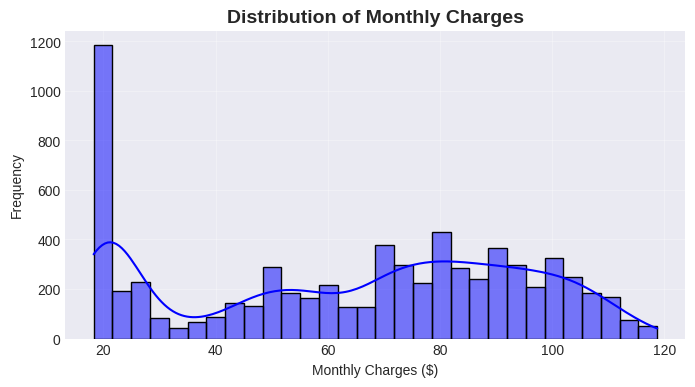


b) Creating charge categories:
   Created 'charge_category' from MonthlyCharges
charge_category
Medium-High    2386
High           1739
Low            1653
Medium-Low     1265
Name: count, dtype: int64

   Created 'tenure_category' from tenure
tenure_category
Loyal         2239
Long-term     1594
New           1481
Mid-term      1024
Short-term     705
Name: count, dtype: int64

   Created 'totalcharge_category' from TotalCharges
totalcharge_category
Very Low       2904
Low            1283
Very High      1135
Medium          652
Medium-High     556
High            513
Name: count, dtype: int64

c) One-hot encoding categorical features:
   Categorical columns to encode: ['charge_category', 'tenure_category', 'totalcharge_category']
   Shape after encoding: (7043, 39)

d) Converting to appropriate dtypes:
   Converted 12 boolean columns to int

e) df_encoded.head():
   is_female  SeniorCitizen  has_partner  has_dependents  tenure  has_phone  \
0          1              0            1   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("🔧 FEATURE ENGINEERING & EXTRACTION")
print("="*70)

# a) Distribution plot (like histplot for bmi)
print("\na) Distribution plot for MonthlyCharges:")
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['MonthlyCharges'], bins=30, kde=True, color='blue')
plt.title('Distribution of Monthly Charges', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# b) Create categorical bins (like bmi_category)
print("\nb) Creating charge categories:")
df_clean['charge_category'] = pd.cut(df_clean['MonthlyCharges'],
                                      bins=[0, 30, 60, 90, 120],
                                      labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
print("   Created 'charge_category' from MonthlyCharges")
print(df_clean['charge_category'].value_counts())

# Create tenure categories
df_clean['tenure_category'] = pd.cut(df_clean['tenure'],
                                      bins=[-1, 6, 12, 24, 48, 72],
                                      labels=['New', 'Short-term', 'Mid-term', 'Long-term', 'Loyal'])
print("\n   Created 'tenure_category' from tenure")
print(df_clean['tenure_category'].value_counts())

# Create total charges categories
df_clean['totalcharge_category'] = pd.cut(df_clean['TotalCharges'],
                                           bins=[0, 1000, 2000, 3000, 4000, 5000, 9000],
                                           labels=['Very Low', 'Low', 'Medium', 'Medium-High', 'High', 'Very High'])
print("\n   Created 'totalcharge_category' from TotalCharges")
print(df_clean['totalcharge_category'].value_counts())

# c) Convert categorical using one-hot encoding
print("\nc) One-hot encoding categorical features:")
# Get categorical columns (object dtype)
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"   Categorical columns to encode: {cat_cols}")

# One-hot encode
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"   Shape after encoding: {df_encoded.shape}")

# d) Convert all to int (where applicable)
print("\nd) Converting to appropriate dtypes:")
# Convert boolean to int
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print(f"   Converted {len(bool_cols)} boolean columns to int")

# e) Check the data
print("\ne) df_encoded.head():")
print(df_encoded.head())

In [ ]:
print("\n" + "="*70)
print("📏 FEATURE SCALING")
print("="*70)

from sklearn.preprocessing import StandardScaler

# Select numerical columns to scale
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"Scaling columns: {cols_to_scale}")

# Create scaler and transform
scaler = StandardScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

print("\nAfter scaling (first 5 rows):")
print(df_encoded[cols_to_scale].head())

print(f"\nMean after scaling (should be ~0):")
print(df_encoded[cols_to_scale].mean().round(4))

print(f"Std after scaling (should be ~1):")
print(df_encoded[cols_to_scale].std().round(4))


📏 FEATURE SCALING
Scaling columns: ['tenure', 'MonthlyCharges', 'TotalCharges']

After scaling (first 5 rows):
     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.992667
1  0.066327       -0.259629     -0.172198
2 -1.236724       -0.362660     -0.958122
3  0.514251       -0.746535     -0.193706
4 -1.236724        0.197365     -0.938930

Mean after scaling (should be ~0):
tenure           -0.0
MonthlyCharges   -0.0
TotalCharges     -0.0
dtype: float64
Std after scaling (should be ~1):
tenure            1.0001
MonthlyCharges    1.0001
TotalCharges      1.0001
dtype: float64


In [ ]:
print("\n" + "="*70)
print("📊 FEATURE SELECTION - CHI-SQUARE TEST")
print("="*70)

from scipy.stats import chi2_contingency

# Set significance level
alpha = 0.05

# Create binned versions of numerical features for chi-square test
df_encoded['MonthlyCharges_bin'] = pd.qcut(df_encoded['MonthlyCharges'], q=4, labels=False, duplicates='drop')
df_encoded['tenure_bin'] = pd.qcut(df_encoded['tenure'], q=4, labels=False, duplicates='drop')
df_encoded['TotalCharges_bin'] = pd.qcut(df_encoded['TotalCharges'], q=4, labels=False, duplicates='drop')

# Identify categorical/binary features
cat_features = [col for col in df_encoded.columns if col not in
                ['MonthlyCharges', 'tenure', 'TotalCharges', 'Churn',
                 'MonthlyCharges_bin', 'tenure_bin', 'TotalCharges_bin']]

print(f"Testing {len(cat_features)} categorical features against Churn...")

# Perform chi-square test for each categorical feature
chi2_results = {}
for col in cat_features:
    try:
        # Create contingency table
        contingency = pd.crosstab(df_encoded[col], df_encoded['Churn'])

        # Perform chi-square test
        chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

        # Decision based on p-value
        decision = '✅ Keep Feature' if p_val < alpha else '❌ Drop Feature'

        chi2_results[col] = {
            'chi2_statistic': chi2_stat,
            'p_value': p_val,
            'decision': decision
        }
    except:
        chi2_results[col] = {
            'chi2_statistic': 0,
            'p_value': 1.0,
            'decision': '❌ Drop Feature (Error)'
        }

# Create DataFrame from results
chi2_df = pd.DataFrame([
    {'feature': feat,
     'chi2_statistic': vals['chi2_statistic'],
     'p_value': vals['p_value'],
     'decision': vals['decision']}
    for feat, vals in chi2_results.items()
])

# Sort by p-value (ascending - most significant first)
chi2_df = chi2_df.sort_values('p_value')

print("\n🏆 TOP 15 MOST SIGNIFICANT FEATURES (Chi-Square Test):")
print("-" * 80)
print(chi2_df.head(15).to_string(index=False))

print(f"\n📊 Summary:")
print(f"   Features to keep (p < {alpha}): {sum(chi2_df['p_value'] < alpha)}")
print(f"   Features to drop (p >= {alpha}): {sum(chi2_df['p_value'] >= alpha)}")


📊 FEATURE SELECTION - CHI-SQUARE TEST
Testing 35 categorical features against Churn...

🏆 TOP 15 MOST SIGNIFICANT FEATURES (Chi-Square Test):
--------------------------------------------------------------------------------
                             feature  chi2_statistic       p_value       decision
         InternetService_Fiber optic      666.808021 4.940476e-147 ✅ Keep Feature
                   Contract_Two year      641.828115 1.337680e-141 ✅ Keep Feature
      PaymentMethod_Electronic check      640.557084 2.528030e-141 ✅ Keep Feature
                TenureGroup_4+ years      486.700621 7.442595e-108 ✅ Keep Feature
DeviceProtection_No internet service      364.519799  2.920300e-81 ✅ Keep Feature
    OnlineBackup_No internet service      364.519799  2.920300e-81 ✅ Keep Feature
                  InternetService_No      364.519799  2.920300e-81 ✅ Keep Feature
  OnlineSecurity_No internet service      364.519799  2.920300e-81 ✅ Keep Feature
     TechSupport_No internet service  

In [ ]:
df_clean.head()

,is_female,SeniorCitizen,has_partner,has_dependents,tenure,has_phone,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,charge_category_High,tenure_category_Short-term,tenure_category_Mid-term,tenure_category_Long-term,tenure_category_Loyal,totalcharge_category_Low,totalcharge_category_Medium,totalcharge_category_Medium-High,totalcharge_category_High,totalcharge_category_Very High
0,1,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
2,0,0,0,0,2,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,45,0,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
print(df_encoded.shape)

(7043, 6560)


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
print(df_encoded.shape)

(7043, 31)


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   is_female                          7043 non-null   int64  
 1   SeniorCitizen                      7043 non-null   int64  
 2   has_partner                        7043 non-null   int64  
 3   has_dependents                     7043 non-null   int64  
 4   tenure                             7043 non-null   int64  
 5   has_phone                          7043 non-null   int64  
 6   MultipleLines                      7043 non-null   int64  
 7   OnlineSecurity                     7043 non-null   int64  
 8   OnlineBackup                       7043 non-null   int64  
 9   DeviceProtection                   7043 non-null   int64  
 10  TechSupport                        7043 non-null   int64  
 11  StreamingTV                        7043 non-null   int64

In [ ]:
#convert bool to int
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [ ]:
df_clean.dtypes.value_counts()

,count
int64,37
float64,2


In [ ]:
#split feature & Target
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

print(X.shape)

(7043, 38)


In [ ]:
#Handle class imbalance
scale_pos_weight = len(y[y==0]) / len(y[y==1])

In [ ]:
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

In [ ]:
#Train-Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 38) (1409, 38)


In [ ]:
#Handle class imbalance
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale_pos_weight)

2.768561872909699


In [ ]:
#Train xgboost model
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

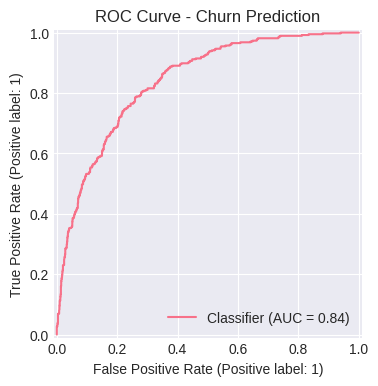

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Churn Prediction")
plt.show()

In [ ]:
#Evaluate model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

[[789 246]
 [ 91 283]]
Accuracy: 0.7608232789212207
Precision: 0.5349716446124764
Recall: 0.7566844919786097
F1: 0.6267995570321152
AUC: 0.8388307628716836


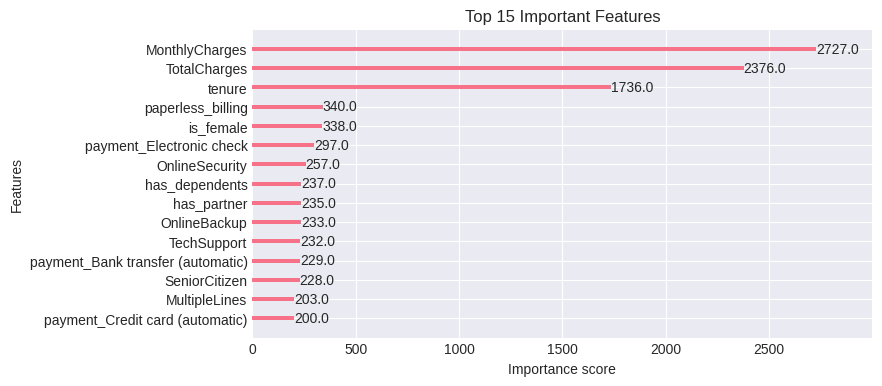

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15)
plt.title("Top 15 Important Features")
plt.show()

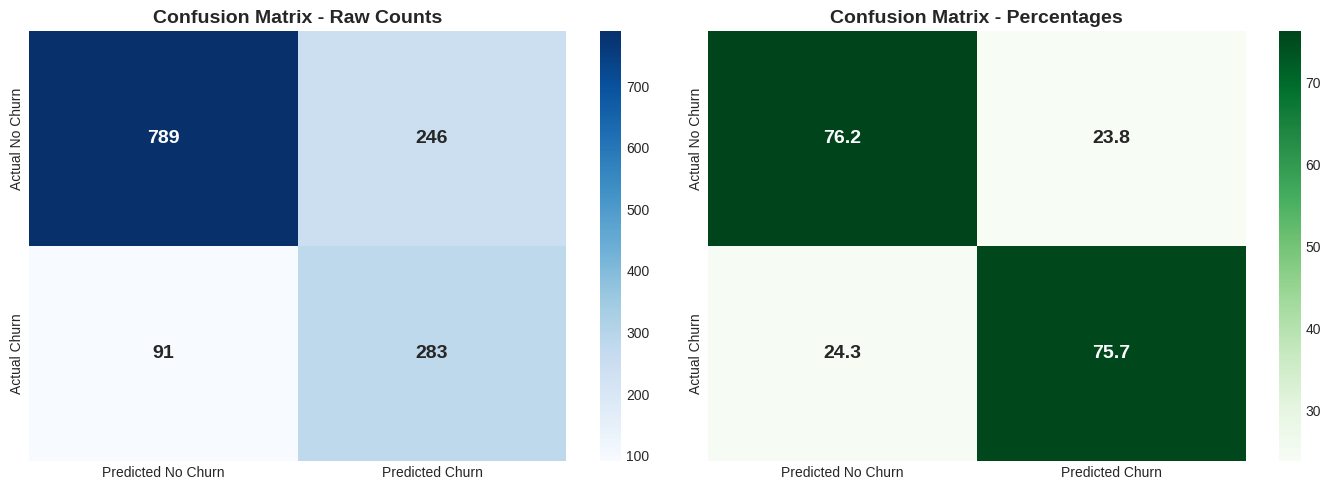


📊 CONFUSION MATRIX INSIGHTS:
   • True Negatives: 911 (correctly predicted non-churners)
   • False Positives: 124 (wasted marketing spend)
   • False Negatives: 176 (missed opportunities)
   • True Positives: 198 (successful interventions)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Standard confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')

# Plot 2: Normalized confusion matrix (percentages)
cm_percent = cm / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
axes[1].set_title('Confusion Matrix - Percentages', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 CONFUSION MATRIX INSIGHTS:")
print(f"   • True Negatives: {tn} (correctly predicted non-churners)")
print(f"   • False Positives: {fp} (wasted marketing spend)")
print(f"   • False Negatives: {fn} (missed opportunities)")
print(f"   • True Positives: {tp} (successful interventions)")


In [ ]:
import joblib

# Save the trained model
joblib.dump(model, "churn_xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!
